# Evaluation and Demo

Import libraries

In [1]:
import torch
from torchinfo import summary
import yaml
from training import Trainer
import os
from utils import get_data, create_model_name
from accelerate import Accelerator # for multigpu
from dotenv import load_dotenv
load_dotenv()  # take environment variables from .env file

# accelerator for multigpu
accelerator = Accelerator()

##### Datasets and splits

In [2]:
# load and split dataset
from torchvision import transforms
from gripper_data import GripperDataset
from utils import split_dataset

torch.manual_seed(6) # for reproducibility

FULL_DATASET_PATH = os.getenv("BIG_DATASET_PATH") 
TOY_DATASET_PATH = os.getenv("DATASET_PATH")

# Preprocessing transforms
top_img_shape = [720, 1280] # original image shape
resize_factor = 16
resize_shape = [int(x//resize_factor) for x in top_img_shape]
preprocess = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize(resize_shape),
        ])


# -- Full dataset --
dataset = GripperDataset(abs_path=FULL_DATASET_PATH, 
                        transform=preprocess,
                        images_to_load=["Images"])        

FULL_DATASET_SPLIT = [70000,20000,10000] # train, val, test
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(dataset, FULL_DATASET_SPLIT)
val_dataset_early_stopping, val_dataset_2 = split_dataset(val_dataset, [10000,10000])

print(f"\nOriginal dataset size: {len(dataset)}")
print(f"- Len train dataset: {len(train_dataset)}",
            f"- Len val dataset: {len(val_dataset)}",
            f"  - Len val dataset for early stopping: {len(val_dataset_early_stopping)}",
            f"  - Len val dataset for comparison: {len(val_dataset_2)}",
            f"- Len test dataset: {len(test_dataset)}", sep="\n")


# -- Toy dataset --
toy_dataset = GripperDataset(abs_path=TOY_DATASET_PATH, 
                        transform=preprocess,
                        images_to_load=["Images"])        

TOY_DATASET_SPLIT = [8000, 2000, 300] # train, val, test
toy_train_dataset, toy_val_dataset, toy_test_dataset = torch.utils.data.random_split(toy_dataset, TOY_DATASET_SPLIT)

print(f"\nToy dataset size: {len(toy_train_dataset) + len(toy_val_dataset) + len(toy_test_dataset)}")
print(f"- Len toy train dataset: {len(toy_train_dataset)}",
            f"- Len toy val dataset: {len(toy_val_dataset)}",
            f"- Len toy test dataset: {len(toy_test_dataset)}", sep="\n")


# DataLoaders
from torch.utils.data import DataLoader
BATCH_SIZE = 32
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
toy_test_loader = DataLoader(toy_test_dataset, batch_size=BATCH_SIZE, shuffle=False)



Original dataset size: 100000
- Len train dataset: 70000
- Len val dataset: 20000
  - Len val dataset for early stopping: 10000
  - Len val dataset for comparison: 10000
- Len test dataset: 10000

Toy dataset size: 10300
- Len toy train dataset: 8000
- Len toy val dataset: 2000
- Len toy test dataset: 300


Datasets with reference images

In [3]:
# load and split dataset
from torchvision import transforms
from gripper_data_ref import GripperDatasetReference
from utils import split_dataset

torch.manual_seed(6) # for reproducibility

FULL_DATASET_PATH = os.getenv("BIG_DATASET_PATH") 
TOY_DATASET_PATH = os.getenv("DATASET_PATH")

# Preprocessing transforms
top_img_shape = [720, 1280] # original image shape
resize_factor = 16
resize_shape = [int(x//resize_factor) for x in top_img_shape]
preprocess = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize(resize_shape),
        ])


# -- Full dataset --
ref_dataset = GripperDatasetReference(abs_path=FULL_DATASET_PATH, 
                        transform=preprocess,
                        images_to_load=["Images"])        

FULL_DATASET_SPLIT = [70000,20000,10000] # train, val, test
ref_train_dataset, ref_val_dataset, ref_test_dataset = torch.utils.data.random_split(ref_dataset, FULL_DATASET_SPLIT)
ref_val_dataset_early_stopping, ref_val_dataset_2 = split_dataset(ref_val_dataset, [10000,10000])

print(f"\nOriginal dataset with references size: {len(ref_dataset)}")
print(f"- Len train dataset: {len(ref_train_dataset)}",
            f"- Len val dataset: {len(ref_val_dataset)}",
            f"  - Len val dataset for early stopping: {len(ref_val_dataset_early_stopping)}",
            f"  - Len val dataset for comparison: {len(ref_val_dataset_2)}",
            f"- Len test dataset: {len(ref_test_dataset)}", sep="\n")


# -- Toy dataset --
ref_toy_dataset = GripperDatasetReference(abs_path=TOY_DATASET_PATH, 
                        transform=preprocess,
                        images_to_load=["Images"])        

TOY_DATASET_SPLIT = [8000, 2000, 300] # train, val, test
ref_toy_train_dataset, ref_toy_val_dataset, ref_toy_test_dataset = torch.utils.data.random_split(ref_toy_dataset, TOY_DATASET_SPLIT)

print(f"\nToy dataset with references size: {len(ref_toy_train_dataset) + len(ref_toy_val_dataset) + len(ref_toy_test_dataset)}")
print(f"- Len toy train dataset: {len(ref_toy_train_dataset)}",
            f"- Len toy val dataset: {len(ref_toy_val_dataset)}",
            f"- Len toy test dataset: {len(ref_toy_test_dataset)}", sep="\n")


# DataLoaders
from torch.utils.data import DataLoader
BATCH_SIZE = 32
ref_test_loader = DataLoader(ref_test_dataset, batch_size=BATCH_SIZE, shuffle=False)
ref_toy_test_loader = DataLoader(ref_toy_test_dataset, batch_size=BATCH_SIZE, shuffle=False)



Original dataset with references size: 100000
- Len train dataset: 70000
- Len val dataset: 20000
  - Len val dataset for early stopping: 10000
  - Len val dataset for comparison: 10000
- Len test dataset: 10000

Toy dataset with references size: 10300
- Len toy train dataset: 8000
- Len toy val dataset: 2000
- Len toy test dataset: 300


In [4]:
from matplotlib import pyplot as plt
def plot_input_vs_reconstruction(img, reconstruction):
    fig, axs = plt.subplots(1,2, figsize=(12,4))
    axs[0].imshow(img.permute(1,2,0))
    axs[0].set_title("Image")
    axs[0].axis('off')
    axs[1].imshow(reconstruction.permute(1,2,0))
    axs[1].set_title("Reconstructed Image")
    axs[1].axis('off')
    plt.show()

def plot_reference_vs_reconstruction_vs_target(reference, reconstruction, target):
    fig, axs = plt.subplots(1,3, figsize=(16,4))
    axs[0].imshow(reference.permute(1,2,0))
    axs[0].set_title("Reference Image")
    axs[0].axis('off')
    axs[1].imshow(reconstruction.permute(1,2,0))
    axs[1].set_title("Reconstructed Image")
    axs[1].axis('off')
    axs[2].imshow(target.permute(1,2,0))
    axs[2].set_title("Target Image")
    axs[2].axis('off')
    plt.show()

# Encoder

# Decoder

## Fourier MLP decoder

In [3]:
decoder_type = "fourier_mlp_decoder"
trained_decoders = os.listdir(os.path.join("trained_models", decoder_type))
print("Available trained decoders:", *trained_decoders, sep="\n- ")

Available trained decoders:
- debug_config_train32_val32_batch32_xyzrg
- debug_datapath_train32_val32_batch32_xyzrg
- debug_freq_train32_val32_batch32_xyzrg
- debug_logger_train32_val32_batch32_xyzrg
- debug_lpips_train32_val32_batch32_xyzrg
- debug_reconstruction_train32_val32_batch32_xyzrg
- debug_save_load_train32_val32_batch32_xyzrg
- debug_train32_val32_batch32_xyzrg
- freq_32_train32_val32_batch32_xyzrg
- freq_64_train32_val32_batch32_xyzrg
- MSE_val10000_batch32_xyzrg_cluster
- train32_val32_batch32_xyzrg


#### Decoder trained with MSE Loss

#### Decoder trained with LPIPS Loss

In [ ]:
MODEL_TO_LOAD = "train32_val32_batch32_xyzrg"

In [14]:
from architecture import FourierMlpDecoder

# load trained model
decoder = FourierMlpDecoder(
    model_name=MODEL_TO_LOAD,
    accelerator=accelerator,
    config=config, # TODO: local config
)
decoder.load_model()
# from accelerate import load_checkpoint_in_model
# load_checkpoint_in_model(decoder,
#                          os.path.join("fourier_mlp_decoder", "debug_save_load_train32_val32_batch32_xyzrg"), 
# )#device_map={"":decoder.device})
decoder = accelerator.prepare(decoder)
summary(decoder, input_size=(1, len(config["model"]["dimensions_to_learn"])))
decoder.eval()
decoder_trainer = Trainer(decoder, config)

Train batch-loss MSE: 0.020593509078025818
Train batch-loss RMSE: 0.1435043869643915
Output shape: (32, 3, 45, 80)
Robot configuration x=0.460, y=0.500, z=0.050, r=0.000, g=1.000


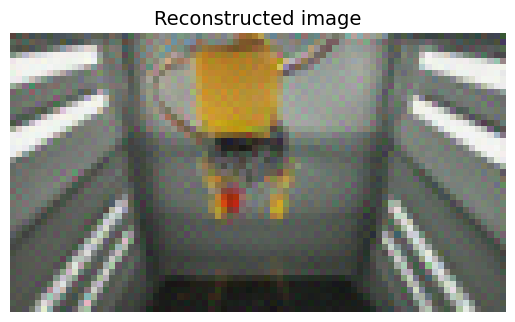

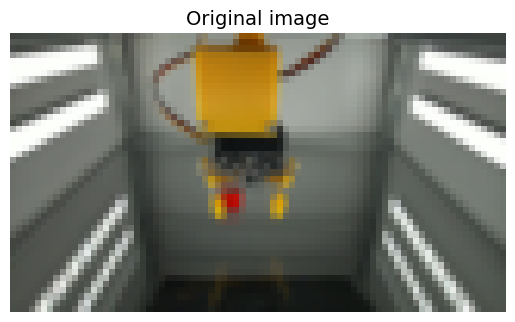

In [15]:
batch = next(iter(train_loader))
images, labels = batch

# inference on train set
output, loss = decoder_trainer._inference_step(batch)
loss = loss.item()
output = output.detach().numpy()

print("Train batch-loss MSE:", loss)
print("Train batch-loss RMSE:", loss**0.5)
print("Output shape:", output.shape)
# plot original and reconstructed images
from gripper_data import plot_image
num_sample = 8
print(f"Robot configuration x={labels[num_sample,0]:.3f}, y={labels[num_sample,1]:.3f}, z={labels[num_sample,2]:.3f}, r={labels[num_sample,3]:.3f}, g={labels[num_sample,4]:.3f}")
plot_image(output[num_sample], title="Reconstructed image")
plot_image(images[num_sample], title="Original image")

 inference on test set

Inference on test set:
Test loss MSE: 0.1273220181465149
Test loss RMSE: 0.35682210994627966
Output shape: (32, 3, 45, 80)
Robot configuration x=0.810, y=0.500, z=0.289, r=0.000, g=1.000


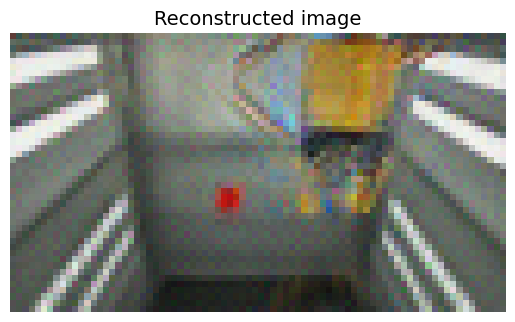

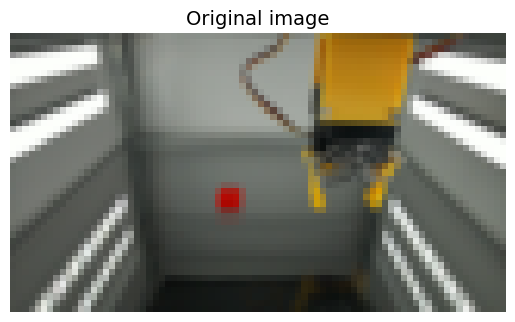

In [18]:
batch = next(iter(test_loader))
images, labels = batch

# inference on train set
output, loss = decoder_trainer._inference_step(batch)
loss = loss.item()
output = output.detach().numpy()

print("Inference on test set:")
print("Test loss MSE:", loss)
print("Test loss RMSE:", loss**0.5)
print("Output shape:", output.shape)
# plot original and reconstructed images
from gripper_data import plot_image
num_sample = 8
print(f"Robot configuration x={labels[num_sample,0]:.3f}, y={labels[num_sample,1]:.3f}, z={labels[num_sample,2]:.3f}, r={labels[num_sample,3]:.3f}, g={labels[num_sample,4]:.3f}")
plot_image(output[num_sample], title="Reconstructed image")
plot_image(images[num_sample], title="Original image")


In [4]:
MODEL_TO_LOAD = "MSE_val10000_batch32_xyzrg_cluster"

In [5]:
from architecture import FourierMlpDecoder

model_path = os.path.join("trained_models", decoder_type, MODEL_TO_LOAD)
config_file = os.path.join("trained_models", decoder_type, MODEL_TO_LOAD, "config.yaml")
with open(config_file, "r") as f:
    config = yaml.safe_load(f)
    config["data"]["dataset_path"] = os.getenv("DATASET_PATH_BIG")

# dataset
train_loader, val_loader, test_loader = get_data(config)

# load trained model
decoder = FourierMlpDecoder(
    model_name=MODEL_TO_LOAD,
    accelerator=accelerator,
    config=config, 
)
decoder.load_model()
# from accelerate import load_checkpoint_in_model
# load_checkpoint_in_model(decoder,
#                          os.path.join("fourier_mlp_decoder", "debug_save_load_train32_val32_batch32_xyzrg"), 
# )#device_map={"":decoder.device})
decoder = accelerator.prepare(decoder)
# decoder.summary(input_size=[(1, 3, 45, 80), (1, len(config["model"]["dimensions_to_learn"]))])
decoder.eval()
decoder_trainer = Trainer(decoder, config)

Train batch-loss MSE: 0.002905134577304125
Train batch-loss RMSE: 0.053899300341508374
Output shape: (32, 3, 45, 80)
Robot configuration x=0.676, y=0.836, z=0.433, r=0.117, g=0.322


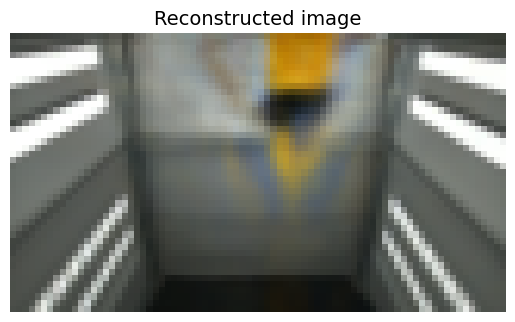

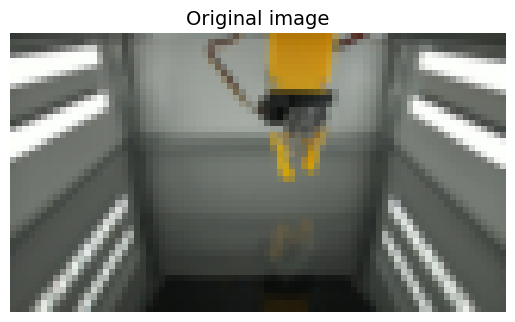

In [11]:
batch = next(iter(train_loader))
images, labels = batch

# inference on train set
output, loss = decoder_trainer._inference_step(batch)
loss = loss.item()
output = output.clamp(0, 1).detach().numpy()

print("Train batch-loss MSE:", loss)
print("Train batch-loss RMSE:", loss**0.5)
print("Output shape:", output.shape)
# plot original and reconstructed images
from gripper_data import plot_image
num_sample = 10
print(f"Robot configuration x={labels[num_sample,0]:.3f}, y={labels[num_sample,1]:.3f}, z={labels[num_sample,2]:.3f}, r={labels[num_sample,3]:.3f}, g={labels[num_sample,4]:.3f}")
plot_image(output[num_sample], title="Reconstructed image")
plot_image(images[num_sample], title="Original image")

## Conditioned UNet

In [5]:
from conditioned_UNet import UNetWithFiLM
decoder_type = "u_net_with_fi_l_m"

# print(f"Current dir \"{os.path.abspath(os.curdir)}\"")
trained_decoders = os.listdir(os.path.join("trained_models", decoder_type))
print("Available trained decoders:", *trained_decoders, sep="\n- ")

Available trained decoders:
- debug_dec
- debug_multi_reference_batch32_xyzrg
- debug_no_tqdm_batch32_xyzrg
- debug_no_tqdm_train32_val32_batch32_xyzrg
- debug_persistent_workers_batch32_xyzrg
- debug_unet_batch32_xyzrg
- debug_unet_train32_val32_batch32_xyzrg


In [6]:
MODEL_TO_LOAD = "debug_unet_batch32_xyzrg"

In [7]:
# load model config
model_path = os.path.join("trained_models", decoder_type, MODEL_TO_LOAD)
config_file = os.path.join("trained_models", decoder_type, MODEL_TO_LOAD, "config.yaml")
with open(config_file, "r") as f:
    config = yaml.safe_load(f)

# load trained model
decoder = UNetWithFiLM(
    model_name=MODEL_TO_LOAD,
    accelerator=accelerator,
    config=config, 
)
decoder.load_model()
decoder = accelerator.prepare(decoder)
# decoder.summary(input_size=[(1, 3, 45, 80), (1, len(config["model"]["dimensions_to_learn"]))])
decoder.eval()
decoder_trainer = Trainer(decoder, config)

Evaluation on test set

- original test set
- toy test set

In [10]:
print("Evaluation on test set:")
dataset_metrics = decoder_trainer.evaluate_model(ref_test_loader)

print("\nEvaluation on test toy dataset")
toy_dataset_metrics = decoder_trainer.evaluate_model(ref_toy_test_loader)

Evaluation on test set:


Testing:   0%|          | 1/313 [00:12<1:04:14, 12.35s/it]


KeyboardInterrupt: 

Demo

Train batch-loss MSE: 0.0014905346324667335
Train batch-loss RMSE: 0.03860744270819726
Output shape: (32, 3, 45, 80)
Robot configuration x=0.970, y=0.500, z=0.089, r=0.000, g=1.000


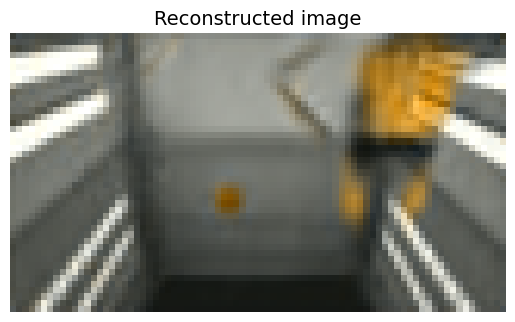

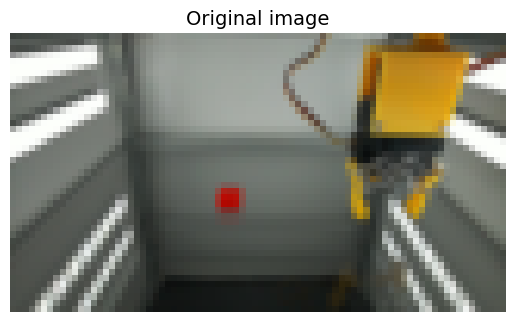

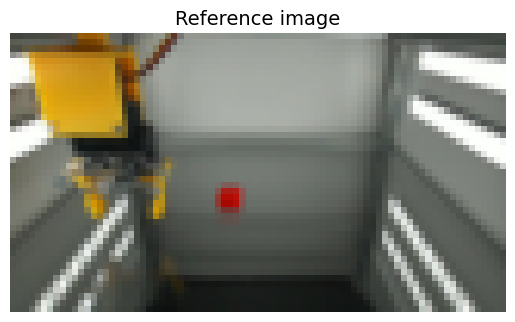

In [18]:
batch = next(iter(train_loader))
images, labels, references, ref_labels = batch

# inference on train set
output, loss = decoder_trainer._inference_step(batch)
loss = loss.item()
output = output.clamp(0, 1).detach().numpy()

print("Train batch-loss MSE:", loss)
print("Train batch-loss RMSE:", loss**0.5)
print("Output shape:", output.shape)
# plot original and reconstructed images
from gripper_data import plot_image
num_sample = 0
print(f"Robot configuration x={labels[num_sample,0]:.3f}, y={labels[num_sample,1]:.3f}, z={labels[num_sample,2]:.3f}, r={labels[num_sample,3]:.3f}, g={labels[num_sample,4]:.3f}")
plot_image(output[num_sample], title="Reconstructed image")
plot_image(images[num_sample], title="Original image")
plot_image(references[num_sample], title="Reference image")